In [40]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [41]:
df.shape


(8807, 12)

In [42]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [43]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [44]:
df = df.dropna(subset=["country", "date_added"])


In [45]:
df["type"].value_counts()


type
Movie      5691
TV Show    2276
Name: count, dtype: int64

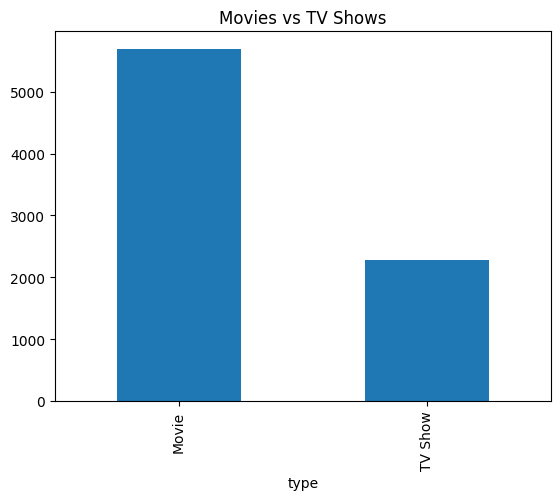

In [46]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.show()


In [47]:
df["country"].value_counts().head(10)


country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

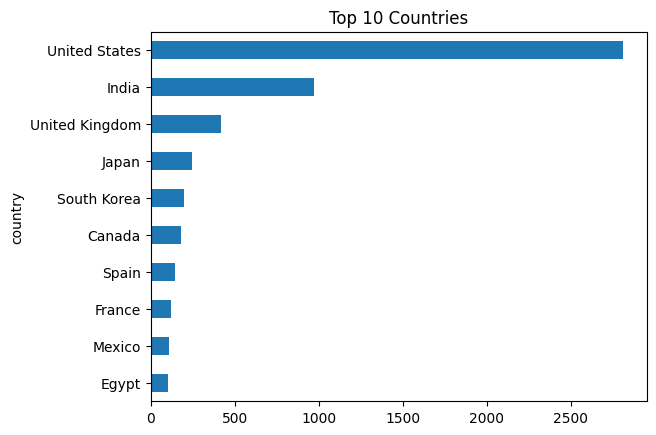

In [48]:
df["country"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Countries")
plt.gca().invert_yaxis()
plt.show()


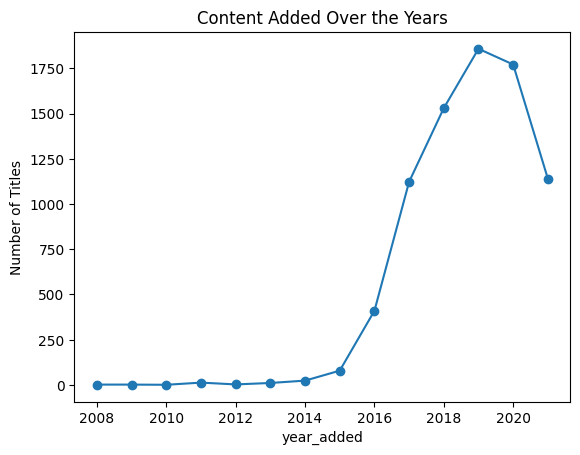

In [49]:

df["date_added"] = pd.to_datetime(df["date_added"].str.strip())


df["year_added"] = df["date_added"].dt.year
df["year_added"].value_counts().sort_index().plot(kind="line", marker='o')

plt.title("Content Added Over the Years")
plt.ylabel("Number of Titles")
plt.show()


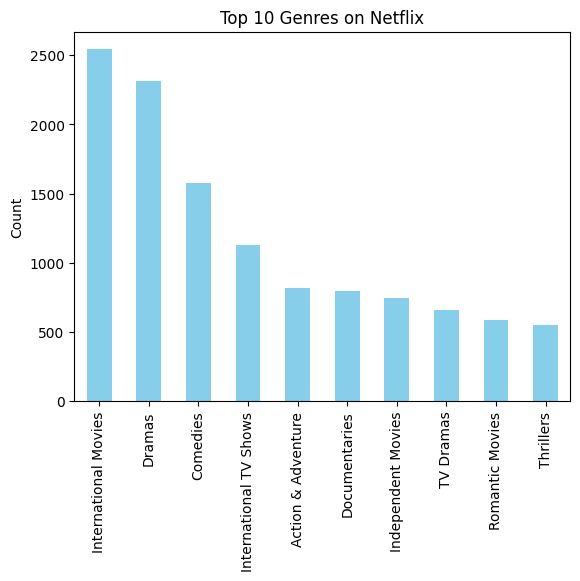

In [50]:
from collections import Counter

all_genres = ", ".join(df["listed_in"]).split(", ")


genre_counts = Counter(all_genres)

# 3. Plot the top 10
pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Genres on Netflix")
plt.ylabel("Count")
plt.show()


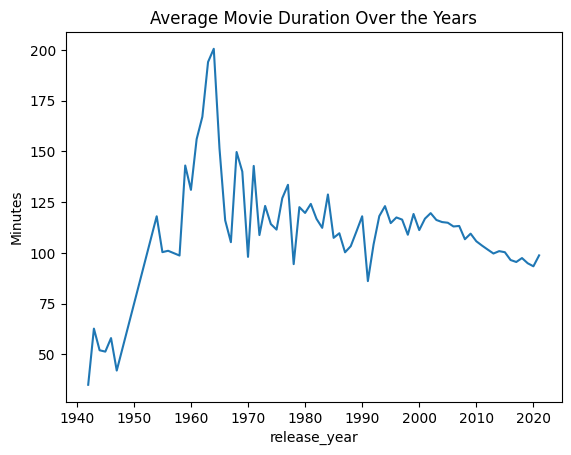

In [51]:

movies = df[df["type"] == "Movie"].copy()


movies["duration_min"] = movies["duration"].str.replace(" min", "").astype(float)


movies.groupby("release_year")["duration_min"].mean().plot()
plt.title("Average Movie Duration Over the Years")
plt.ylabel("Minutes")
plt.show()
